# Payoff structures — NIFTY options

Straddle · strangle · iron fly · iron condor · naked call and put.

One trading day: **27 Jan 2026**, expiry **10 Feb 2026**, lot size **65**.

A strategy is a **list of legs**. Every figure below comes from one payoff function and one metrics
function — no per-strategy code.

## 1. Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "Data" / "sample" / "chain_2026-01-27.parquet"

# NIFTY lot size, confirmed 65 on 19 Aug 2026 (map #1). Margin mechanics stay open in issue #4.
LOT_SIZE = 65

TRADING_DAYS_PER_YEAR = 252  # established in issue #2

## 2. The data

NIFTY option chain, 1-minute bars, one session.

- `ts` is **UTC**. Source options are IST stamped at bar close, greeks UTC at bar open — a naive join
  returns zero rows and no warning.
- `dte_days` is a **trading-day clock**: one session consumes exactly 1.0, overnight and weekends none.
- Prices are the bar close, which is what `last` holds.

In [2]:
chain = pd.read_parquet(SAMPLE)
chain["ist"] = chain.ts + pd.Timedelta(hours=5, minutes=30)

print(f"rows      {len(chain):,}")
print(f"session   {chain.ist.min():%H:%M} -> {chain.ist.max():%H:%M} IST on {chain.ist.dt.date.iloc[0]}")
print(f"strikes   {chain.strike.nunique()}  ({chain.strike.min():.0f} - {chain.strike.max():.0f})")
print(f"dte_days  {chain.dte_days.max():.4f} at open -> {chain.dte_days.min():.4f} at close")
chain.head(3)

rows      23,581
session   09:15 -> 15:30 IST on 2026-01-27
strikes   94  (23300 - 27950)
dte_days  11.0000 at open -> 10.0000 at close


,ts,strike,option_type,Open,High,Low,Close,Volume,OpenInterest,Ticker,...,delta,gamma,theta,vega,rho,vanna,volga,charm,spot,ist
0,2026-01-27 03:45:00,23350.0,PE,19.15,19.35,19.0,19.0,1170,0,NIFTY10FEB2623350PE.NFO,...,-0.040644,0.000077,-4.294955,4.589929,-0.454762,-0.006859,0.628664,0.006734,25113.05,2026-01-27 09:15:00
1,2026-01-27 03:45:00,23400.0,PE,22.05,22.25,20.5,20.5,1755,20280,NIFTY10FEB2623400PE.NFO,...,-0.043716,0.000082,-4.531928,4.868650,-0.489155,-0.007188,0.645895,0.007020,25113.05,2026-01-27 09:15:00
2,2026-01-27 03:45:00,23450.0,PE,23.75,23.75,21.4,21.4,1820,4355,NIFTY10FEB2623450PE.NFO,...,-0.045958,0.000087,-4.658043,5.068765,-0.514183,-0.007489,0.663581,0.007221,25113.05,2026-01-27 09:15:00


### Moment

Midday IST — liquid, clear of the open and close auctions.

In [3]:
SNAPSHOT_TIME = pd.Timestamp("2026-01-27 12:00:00")

snap = chain[chain.ist == SNAPSHOT_TIME].copy()

SPOT     = float(snap.spot.iloc[0])
FORWARD  = float(snap.forward.iloc[0])
DISCOUNT = float(snap.discount.iloc[0])
DTE      = float(snap.dte_days.iloc[0])
T        = DTE / TRADING_DAYS_PER_YEAR

print(f"spot      {SPOT:,.2f}")
print(f"forward   {FORWARD:,.2f}   (basis {FORWARD - SPOT:+.2f} points)")
print(f"discount  {DISCOUNT:.6f}")
print(f"dte_days  {DTE:.4f}   ->  T = {DTE:.4f}/252 = {T:.6f} years")
print(f"legs available: {len(snap)} across {snap.strike.nunique()} strikes")

spot      25,100.25
forward   25,219.12   (basis +118.87 points)
discount  0.993480
dte_days  10.5600   ->  T = 10.5600/252 = 0.041905 years
legs available: 58 across 49 strikes


## 3. Legs and strategies

A **leg** is one contract: strike, type, direction, quantity, entry price.
A **strategy** is a list of legs — an iron condor is four legs, not a type.

In [4]:
@dataclass(frozen=True)
class Leg:
    strike: float
    option_type: str      # "CE" or "PE"
    direction: int        # +1 bought, -1 sold
    entry_price: float
    iv: float
    quantity: int = 1

    @property
    def is_call(self):
        return self.option_type == "CE"

    def __repr__(self):
        side = "B" if self.direction > 0 else "S"
        return f"{side} {self.quantity}x {self.strike:.0f} {self.option_type} @ {self.entry_price:.2f}"


def leg_from_chain(strike, option_type, direction, quantity=1, snapshot=None):
    '''Build a Leg from the observed chain. Entry price is the 1-min bar close.'''
    snapshot = snap if snapshot is None else snapshot
    row = snapshot[(snapshot.strike == strike) & (snapshot.option_type == option_type)]
    if row.empty:
        raise KeyError(f"{strike:.0f} {option_type} not quoted at this minute")
    row = row.iloc[0]
    return Leg(strike, option_type, direction, float(row.last), float(row.iv), quantity)

### Strikes

At-the-money is the strike nearest the **forward**, not the spot. They differ by ~119 points here,
more than two strike intervals.

In [5]:
quoted = snap.groupby("strike").option_type.nunique()
both_sides = set(quoted[quoted == 2].index)          # strikes with a live CE and PE

ATM = min(both_sides, key=lambda k: abs(k - FORWARD))
WING = 300
OTM_CALL = min((k for k in both_sides if k >= ATM + WING), default=None)
OTM_PUT  = max((k for k in both_sides if k <= ATM - WING), default=None)

# Wings for the four-legged structures. A condor wing is a single option, so it does not need
# the strike quoted on both sides - and at this minute nothing above 25,500 is. Restricting the
# wings to `both_sides` would leave the far call wing unbuildable.
ce_strikes = set(snap.loc[snap.option_type == "CE", "strike"])
pe_strikes = set(snap.loc[snap.option_type == "PE", "strike"])

NEAR, FAR = 300, 600
FLY_CALL    = min(k for k in ce_strikes if k >= ATM + NEAR)
FLY_PUT     = max(k for k in pe_strikes if k <= ATM - NEAR)
CONDOR_CALL = min(k for k in ce_strikes if k >= ATM + FAR)
CONDOR_PUT  = max(k for k in pe_strikes if k <= ATM - FAR)

print(f"forward        {FORWARD:,.2f}")
print(f"ATM strike     {ATM:,.0f}")
print(f"strangle wings {OTM_PUT:,.0f} PE / {OTM_CALL:,.0f} CE")
print(f"fly wings      {FLY_PUT:,.0f} PE / {FLY_CALL:,.0f} CE")
print(f"condor wings   {CONDOR_PUT:,.0f} PE / {CONDOR_CALL:,.0f} CE")

STRATEGIES = {
    "Long Straddle":   [leg_from_chain(ATM, "CE", +1), leg_from_chain(ATM, "PE", +1)],
    "Short Straddle":  [leg_from_chain(ATM, "CE", -1), leg_from_chain(ATM, "PE", -1)],
    "Long Strangle":   [leg_from_chain(OTM_CALL, "CE", +1), leg_from_chain(OTM_PUT, "PE", +1)],
    "Iron Fly":        [leg_from_chain(ATM, "CE", -1), leg_from_chain(ATM, "PE", -1),
                        leg_from_chain(FLY_CALL, "CE", +1), leg_from_chain(FLY_PUT, "PE", +1)],
    "Iron Condor":     [leg_from_chain(FLY_CALL, "CE", -1), leg_from_chain(FLY_PUT, "PE", -1),
                        leg_from_chain(CONDOR_CALL, "CE", +1), leg_from_chain(CONDOR_PUT, "PE", +1)],
    "Naked Long Call":  [leg_from_chain(ATM, "CE", +1)],
    "Naked Short Call": [leg_from_chain(ATM, "CE", -1)],
    "Naked Long Put":   [leg_from_chain(ATM, "PE", +1)],
    "Naked Short Put":  [leg_from_chain(ATM, "PE", -1)],
}

for name, legs in STRATEGIES.items():
    print(f"  {name:<18} {legs}")

forward        25,219.12
ATM strike     25,200
strangle wings 24,800 PE / 25,500 CE
fly wings      24,900 PE / 25,500 CE
condor wings   24,600 PE / 25,800 CE
  Long Straddle      [B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70]
  Short Straddle     [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70]
  Long Strangle      [B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10]
  Iron Fly           [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 25500 CE @ 206.20, B 1x 24900 PE @ 208.05]
  Iron Condor        [S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 25800 CE @ 115.60, B 1x 24600 PE @ 130.20]
  Naked Long Call    [B 1x 25200 CE @ 344.05]
  Naked Short Call   [S 1x 25200 CE @ 344.05]
  Naked Long Put     [B 1x 25200 PE @ 326.70]
  Naked Short Put    [S 1x 25200 PE @ 326.70]


## 4. Payoff at expiry

Intrinsic value only — all time value has decayed.

$$C_T = \max(S-K,\;0) \qquad P_T = \max(K-S,\;0)$$

Per leg, with direction $d=\pm 1$, quantity $q$, entry price $e$:

$$\Pi_{\text{leg}}(S) = d\,q\,\bigl(V(S) - e\bigr)$$

Strategy over $n$ legs at lot size $L$:

$$\Pi(S) \;=\; L \sum_{i=1}^{n} d_i\,q_i \bigl(V_i(S) - e_i\bigr)$$

One sum, any number of legs.

In [6]:
def intrinsic_value(spot, strike, is_call):
    spot = np.asarray(spot, float)
    return np.maximum(spot - strike, 0.0) if is_call else np.maximum(strike - spot, 0.0)


def payoff_at_expiry(spot, legs, lot_size=1):
    '''Strategy P&L per lot at expiry, for a scalar or array of terminal spots.'''
    total = np.zeros_like(np.asarray(spot, float))
    for leg in legs:
        value = intrinsic_value(spot, leg.strike, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


# sanity check: a long straddle must lose exactly the premium paid if spot lands on the strike
straddle = STRATEGIES["Long Straddle"]
premium = sum(l.direction * l.quantity * l.entry_price for l in straddle)
at_strike = payoff_at_expiry(ATM, straddle)
print(f"premium paid          {premium:,.2f}")
print(f"P&L if spot ends {ATM:,.0f}  {at_strike:,.2f}")
assert np.isclose(at_strike, -premium)
print("check passed")

premium paid          670.75
P&L if spot ends 25,200  -670.75
check passed


## 5. Max profit, max loss, breakevens

$\Pi$ is piecewise linear in $S$ and bends only at a strike, so the extremes are exact rather than
searched for. Candidate points:

$$\mathcal{K} = \{0\} \cup \{K_1, \dots, K_m\}$$

Tail slopes:

$$s_{\text{right}} = \sum_{\text{calls}} d_i q_i
\qquad
s_{\text{left}} = -\sum_{\text{puts}} d_i q_i$$

$$\text{max profit} =
\begin{cases}
\infty & s_{\text{right}} > 0\\[2pt]
\max_{S \in \mathcal{K}} \Pi(S) & \text{otherwise}
\end{cases}
\qquad
\text{max loss} =
\begin{cases}
-\infty & s_{\text{right}} < 0\\[2pt]
\min_{S \in \mathcal{K}} \Pi(S) & \text{otherwise}
\end{cases}$$

**Only the right tail is unbounded.** $S \ge 0$, so the left tail terminates — which is why $0$ is a
candidate point. A long put feels unlimited as the index collapses and is not: its profit stops at
$K - e$.

Breakevens: $\Pi$ is affine between adjacent candidates, so every sign change yields one root

$$S^{*} = S_j - \Pi(S_j)\,\frac{S_{j+1} - S_j}{\Pi(S_{j+1}) - \Pi(S_j)}$$

A strategy may have none, one or several.

In [7]:
def strategy_metrics(legs, lot_size=1):
    strikes = sorted({leg.strike for leg in legs})

    right_slope = sum(l.direction * l.quantity for l in legs if l.is_call)
    left_slope  = -sum(l.direction * l.quantity for l in legs if not l.is_call)

    # candidates: every kink, plus S = 0 where the left tail terminates
    candidates = payoff_at_expiry(np.array([0.0] + strikes, float), legs, lot_size)

    # only the upside is genuinely unbounded - the spot cannot fall below zero
    max_profit = np.inf if right_slope > 0 else float(candidates.max())
    max_loss = -np.inf if right_slope < 0 else float(candidates.min())

    # breakevens: fine scan for sign changes, then solve exactly inside each bracket
    pad = max(strikes[-1] - strikes[0], 1000) + 2000
    grid = np.linspace(0.0, strikes[-1] + pad, 20_000)
    pnl = payoff_at_expiry(grid, legs, lot_size)
    breakevens = []
    for i in np.where(np.sign(pnl[:-1]) * np.sign(pnl[1:]) < 0)[0]:
        root = brentq(lambda s: payoff_at_expiry(s, legs, lot_size), grid[i], grid[i + 1])
        breakevens.append(round(float(root), 2))

    net = sum(l.direction * l.quantity * l.entry_price for l in legs) * lot_size
    return {
        "max_profit": max_profit,
        "max_loss": max_loss,
        "breakevens": breakevens,
        "net_premium": net,          # positive = paid (debit), negative = received (credit)
        "left_slope": left_slope,
        "right_slope": right_slope,
    }


def fmt(x):
    if x == np.inf:
        return "Unlimited"
    if x == -np.inf:
        return "Unlimited"
    return f"{x:,.0f}"


for name, legs in STRATEGIES.items():
    m = strategy_metrics(legs, LOT_SIZE)
    kind = "debit" if m["net_premium"] > 0 else "credit"
    print(f"{name:<18} max profit {fmt(m['max_profit']):>10}   "
          f"max loss {fmt(m['max_loss']):>10}   "
          f"breakevens {m['breakevens']}   net {abs(m['net_premium']):,.0f} {kind}")

Long Straddle      max profit  Unlimited   max loss    -43,599   breakevens [24529.25, 25870.75]   net 43,599 debit
Short Straddle     max profit     43,599   max loss  Unlimited   breakevens [24529.25, 25870.75]   net 43,599 credit
Long Strangle      max profit  Unlimited   max loss    -25,109   breakevens [24413.7, 25886.3]   net 25,109 debit
Iron Fly           max profit     16,672   max loss     -2,828   breakevens [24943.5, 25456.5]   net 16,672 credit
Iron Condor        max profit     10,949   max loss     -8,551   breakevens [24731.55, 25668.45]   net 10,949 credit
Naked Long Call    max profit  Unlimited   max loss    -22,363   breakevens [25544.05]   net 22,363 debit
Naked Short Call   max profit     22,363   max loss  Unlimited   breakevens [25544.05]   net 22,363 credit
Naked Long Put     max profit  1,616,764   max loss    -21,236   breakevens [24873.3]   net 21,236 debit
Naked Short Put    max profit     21,236   max loss -1,616,764   breakevens [24873.3]   net 21,236 cred

## 6. The charts

Worked from the chain at this minute, $L = 65$.

### Short straddle — sell 25200 CE @ 344.05, sell 25200 PE @ 326.70

$d = -1$, $q = 1$, $K = 25200$ for both legs.

$$\Pi_{\text{premium}} = -(344.05 + 326.70)\times 65 = -43{,}598.75 \quad \text{(credit)}$$

Candidates $\mathcal{K} = \{0,\; 25200\}$:

$$\Pi(0) = \bigl[-(0 - 344.05) - (25200 - 326.70)\bigr] \times 65
        = -24{,}529.25 \times 65 = -1{,}594{,}401.25$$

$$\Pi(25200) = \bigl[344.05 + 326.70\bigr] \times 65 = 670.75 \times 65 = 43{,}598.75$$

$s_{\text{right}} = -1 < 0 \Rightarrow$ the loss is unbounded; $s_{\text{left}} = +1$.

$$\text{max profit} = 43{,}598.75 \qquad \text{max loss} = -\infty$$

$\Pi = 0$ at the strike $\mp$ the premium per unit:

$$25200 \mp 670.75 \;=\; 24{,}529.25,\quad 25{,}870.75$$

### Iron condor — sell 25500 CE @ 206.20 and 24900 PE @ 208.05, buy 25800 CE @ 115.60 and 24600 PE @ 130.20

$$-206.20 - 208.05 + 115.60 + 130.20 = -168.45
\;\Rightarrow\; -168.45 \times 65 = -10{,}949.25 \quad \text{(credit)}$$

Both wings bought $\Rightarrow s_{\text{left}} = s_{\text{right}} = 0$: both tails flat, both caps finite.

$$\text{max profit} = \text{credit} = 10{,}949.25$$

$$\text{max loss} = \text{credit} - wL = 10{,}949.25 - 300 \times 65 = -8{,}550.75$$

The credit erodes outward from each short strike:

$$24900 - 168.45 = 24{,}731.55 \qquad 25500 + 168.45 = 25{,}668.45$$

Charts: green above zero, red below; dashed line is spot, dotted lines are breakevens.

In [8]:
def plot_strategy(name, legs, lot_size=LOT_SIZE, width=0.06, ax=None):
    lo, hi = SPOT * (1 - width), SPOT * (1 + width)
    grid = np.linspace(lo, hi, 400)

    expiry = payoff_at_expiry(grid, legs, lot_size)
    m = strategy_metrics(legs, lot_size)

    if ax is None:
        _, ax = plt.subplots()

    ax.fill_between(grid, expiry, 0, where=expiry >= 0, color="#22c55e", alpha=0.18, interpolate=True)
    ax.fill_between(grid, expiry, 0, where=expiry < 0,  color="#ef4444", alpha=0.18, interpolate=True)
    ax.plot(grid, expiry, color="#16a34a", lw=2.0, label="On expiry")

    ax.axhline(0, color="#64748b", lw=1)
    ax.axvline(SPOT, color="#94a3b8", ls="--", lw=1.2, label=f"Spot {SPOT:,.0f}")
    for be in m["breakevens"]:
        if lo <= be <= hi:
            ax.axvline(be, color="#f59e0b", ls=":", lw=1.2)
            ax.annotate(f"{be:,.0f}", (be, 0), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color="#b45309")

    ax.set_title(
        f"{name}   |   max profit {fmt(m['max_profit'])}   max loss {fmt(m['max_loss'])}",
        fontsize=12, loc="left",
    )
    ax.set_xlabel("NIFTY spot at expiry")
    ax.set_ylabel(f"Profit / loss  ({lot_size} per lot)")
    ax.legend(loc="upper center", frameon=False, ncol=2, fontsize=9)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
    return ax

### Straddle and strangle

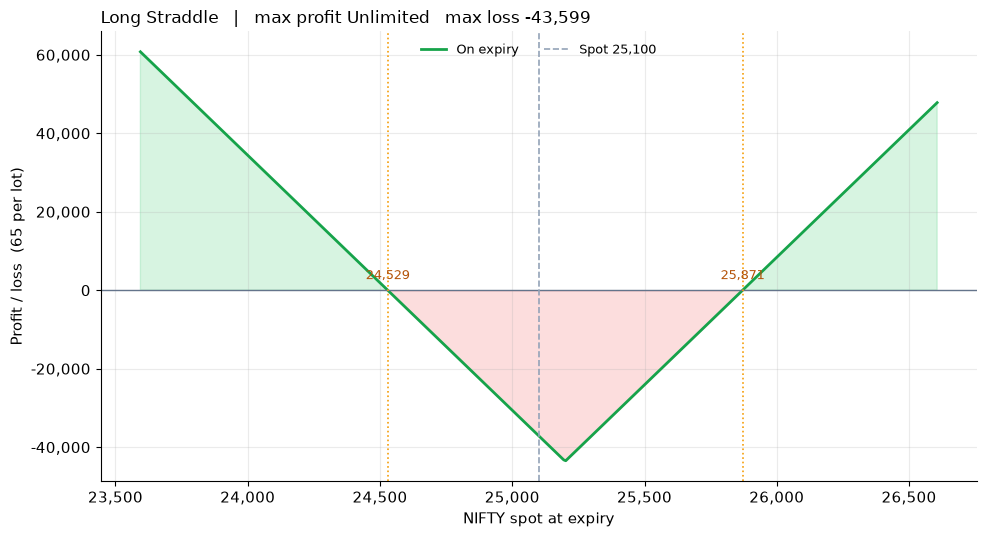

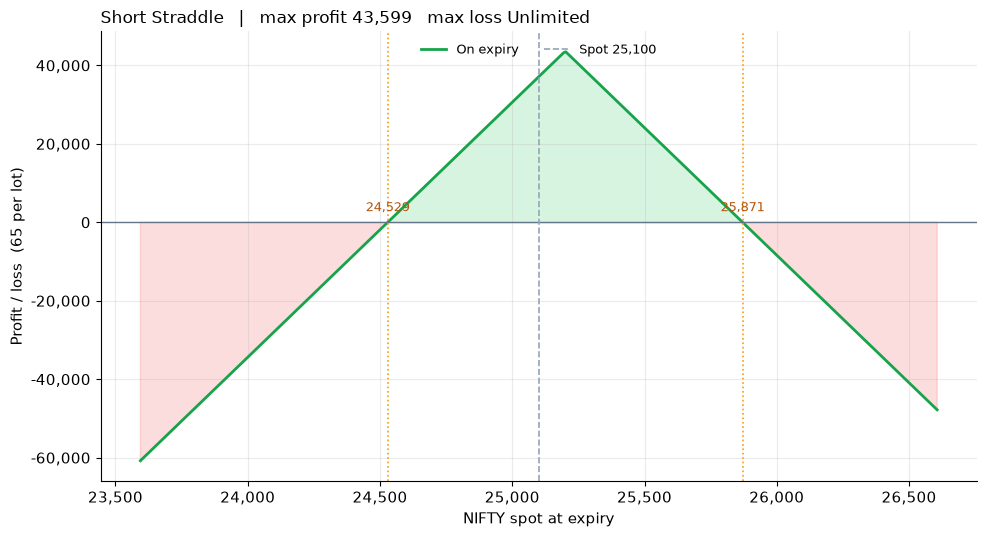

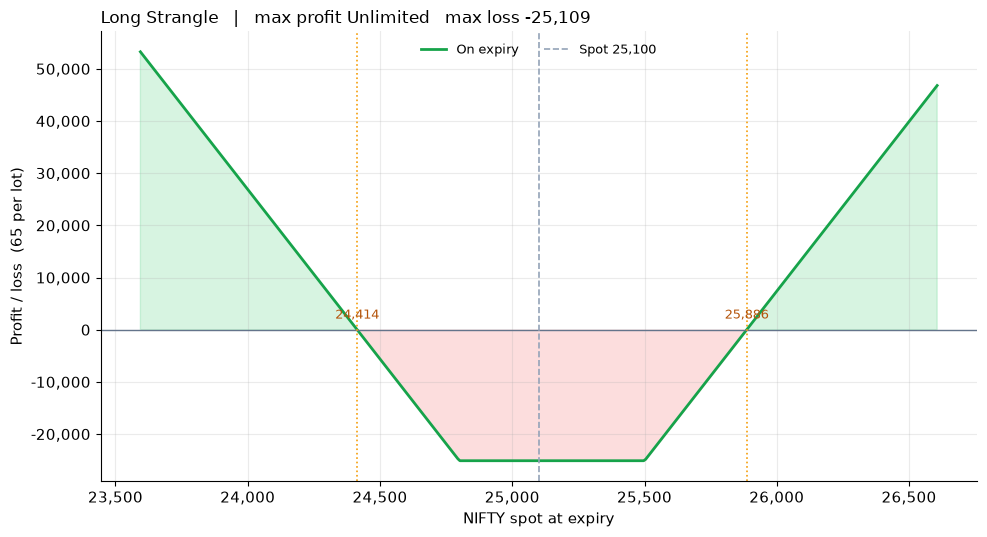

In [9]:
for name in ["Long Straddle", "Short Straddle", "Long Strangle"]:
    plot_strategy(name, STRATEGIES[name])
    plt.tight_layout()
    plt.show()

### Iron condor and iron fly

The first **defined-risk** structures — everything above has an open tail. A bought option beyond
each short leg caps both ends.

- **Iron fly** — short ATM straddle, wings 300 points out.
- **Iron condor** — short strangle 300 out, wings 600 out.

Four legs each, no new code.

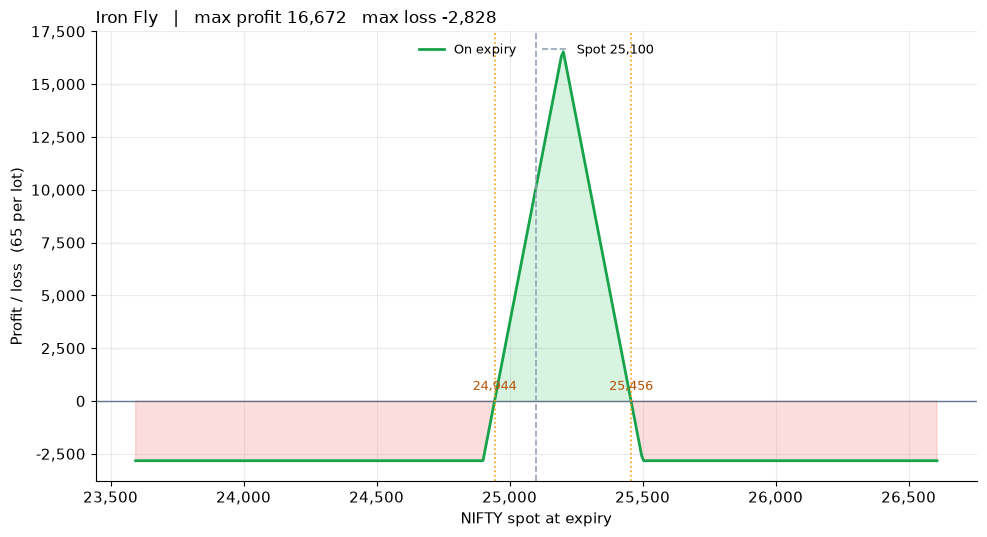

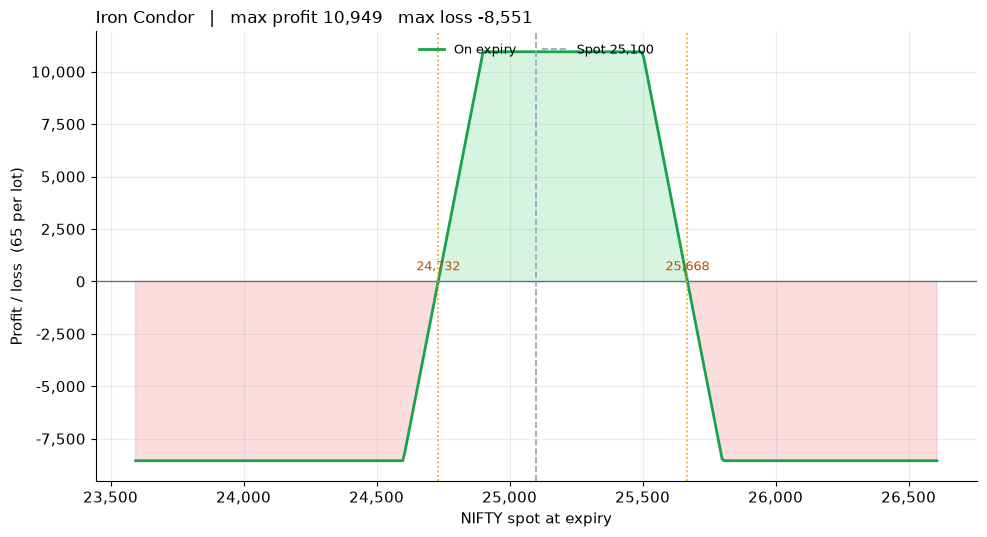

In [10]:
for name in ["Iron Fly", "Iron Condor"]:
    plot_strategy(name, STRATEGIES[name])
    plt.tight_layout()
    plt.show()

#### Caps against the arithmetic

For a credit structure with symmetric wings of width $w$, both caps are forced:

$$\text{max profit} = \text{credit} \qquad \text{max loss} = \text{credit} - wL$$

The assertions below fail the notebook — and the `execute` CI job — if the engine ever disagrees.

In [11]:
for name, put_width, call_width in [
    ("Iron Fly",    ATM - FLY_PUT,        FLY_CALL - ATM),
    ("Iron Condor", FLY_PUT - CONDOR_PUT, CONDOR_CALL - FLY_CALL),
]:
    m = strategy_metrics(STRATEGIES[name], LOT_SIZE)
    assert put_width == call_width, f"{name}: wings {put_width:.0f} / {call_width:.0f} are not symmetric"

    credit = -m["net_premium"]                      # net_premium is negative when we are paid
    risk = call_width * LOT_SIZE
    expected_loss = credit - risk

    assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
    assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
    assert abs(m["max_loss"] - expected_loss) < 1e-6, f"{name}: max loss != credit - wing x lot"

    print(f"{name}")
    print(f"  wing width   {call_width:,.0f} points x {LOT_SIZE} = {risk:,.2f}")
    print(f"  net credit   {credit:,.2f}")
    print(f"  max profit   {m['max_profit']:,.2f}   = credit")
    print(f"  max loss     {m['max_loss']:,.2f}   = credit - wing x lot")
    print(f"  breakevens   {m['breakevens']}")
    print(f"  risk/reward  1 : {credit / -m['max_loss']:.2f}")

Iron Fly
  wing width   300 points x 65 = 19,500.00
  net credit   16,672.50
  max profit   16,672.50   = credit
  max loss     -2,827.50   = credit - wing x lot
  breakevens   [24943.5, 25456.5]
  risk/reward  1 : 5.90
Iron Condor
  wing width   300 points x 65 = 19,500.00
  net credit   10,949.25
  max profit   10,949.25   = credit
  max loss     -8,550.75   = credit - wing x lot
  breakevens   [24731.55, 25668.45]
  risk/reward  1 : 1.28


### Naked call and put

The building blocks. One leg each, same two functions.

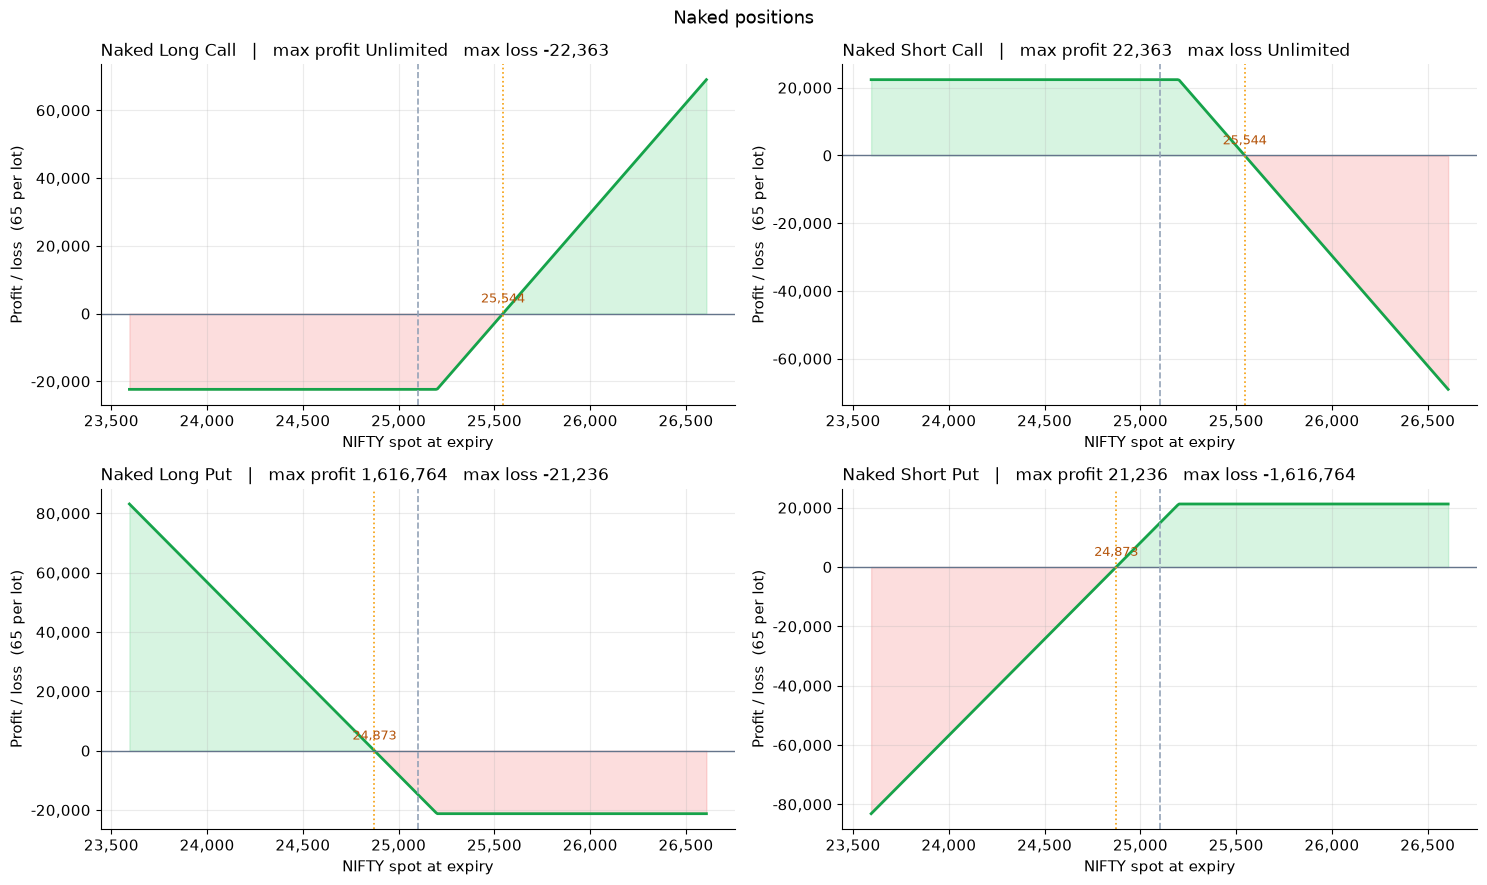

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, name in zip(axes.flat, ["Naked Long Call", "Naked Short Call",
                                "Naked Long Put", "Naked Short Put"]):
    plot_strategy(name, STRATEGIES[name], ax=ax)
    ax.legend().remove()
fig.suptitle("Naked positions", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary

In [13]:
rows = []
for name, legs in STRATEGIES.items():
    m = strategy_metrics(legs, LOT_SIZE)
    rows.append({
        "Strategy": name,
        "Legs": ", ".join(repr(l) for l in legs),
        "Max Profit": fmt(m["max_profit"]),
        "Max Loss": fmt(m["max_loss"]),
        "Breakeven(s)": ", ".join(f"{b:,.0f}" for b in m["breakevens"]) or "-",
        "Net Premium": f"{abs(m['net_premium']):,.0f} {'Dr' if m['net_premium'] > 0 else 'Cr'}",
    })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
summary

,Strategy,Legs,Max Profit,Max Loss,Breakeven(s),Net Premium
0,Long Straddle,"B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70",Unlimited,"-43,599","24,529, 25,871","43,599 Dr"
1,Short Straddle,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70","43,599",Unlimited,"24,529, 25,871","43,599 Cr"
2,Long Strangle,"B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10",Unlimited,"-25,109","24,414, 25,886","25,109 Dr"
3,Iron Fly,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 255...","16,672","-2,828","24,944, 25,456","16,672 Cr"
4,Iron Condor,"S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 258...","10,949","-8,551","24,732, 25,668","10,949 Cr"
5,Naked Long Call,B 1x 25200 CE @ 344.05,Unlimited,"-22,363","25,544","22,363 Dr"
6,Naked Short Call,S 1x 25200 CE @ 344.05,"22,363",Unlimited,"25,544","22,363 Cr"
7,Naked Long Put,B 1x 25200 PE @ 326.70,"1,616,764","-21,236","24,873","21,236 Dr"
8,Naked Short Put,S 1x 25200 PE @ 326.70,"21,236","-1,616,764","24,873","21,236 Cr"
